In [3]:
# ==============================================================================
# CELL 1: Imports & Configuration
# DATASET REFERENCE (MNC Grade Benchmarking)
# Dataset 1: Flickr8k — https://www.kaggle.com/datasets/adityajn105/flickr8k
# Dataset 2: COCO 2017 — https://www.kaggle.com/datasets/awsaf49/coco-2017-dataset
# ==============================================================================

import os
import json
import requests
import warnings
from datetime import datetime

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    BlipForQuestionAnswering
)

warnings.filterwarnings('ignore')

# ── Config File Load ──────────────────────────────────────────────────────────
CONFIG_PATH = '../config/model_config.json'

with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

# ── Device Setup ──────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Output & Data Paths ───────────────────────────────────────────────────────
DATA_DIR    = '../data'
OUTPUT_DIR  = '../outputs'
LOG_FILE    = os.path.join(OUTPUT_DIR, 'predictions_log.txt')
IMAGE_PATH  = os.path.join(DATA_DIR, 'sample_scene.jpg')

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Print Configuration Summary ───────────────────────────────────────────────
print('=' * 60)
print('   🤖 MULTI-MODAL AI AGENT — CONFIGURATION')
print('=' * 60)
print(f'  📌 Device            : {DEVICE.upper()}')
print(f'  📌 Caption Model     : {config["model_name"]}')
print(f'  📌 VQA Model         : {config["vqa_model_name"]}')
print(f'  📌 Beam Search       : {config["num_beams"]} beams')
print(f'  📌 Max Output Tokens : {config["max_new_tokens"]}')
print(f'  📌 Dataset Ref       : {config["dataset_reference"]["name"]}')
print(f'  📌 Output Log        : {LOG_FILE}')
print('=' * 60)

   🤖 MULTI-MODAL AI AGENT — CONFIGURATION
  📌 Device            : CPU
  📌 Caption Model     : Salesforce/blip-image-captioning-large
  📌 VQA Model         : Salesforce/blip-vqa-base
  📌 Beam Search       : 5 beams
  📌 Max Output Tokens : 100
  📌 Dataset Ref       : Flickr8k
  📌 Output Log        : ../outputs\predictions_log.txt


🔽 Sample scene image download ho rahi hai...
✅ Image saved: ../data\sample_scene.jpg


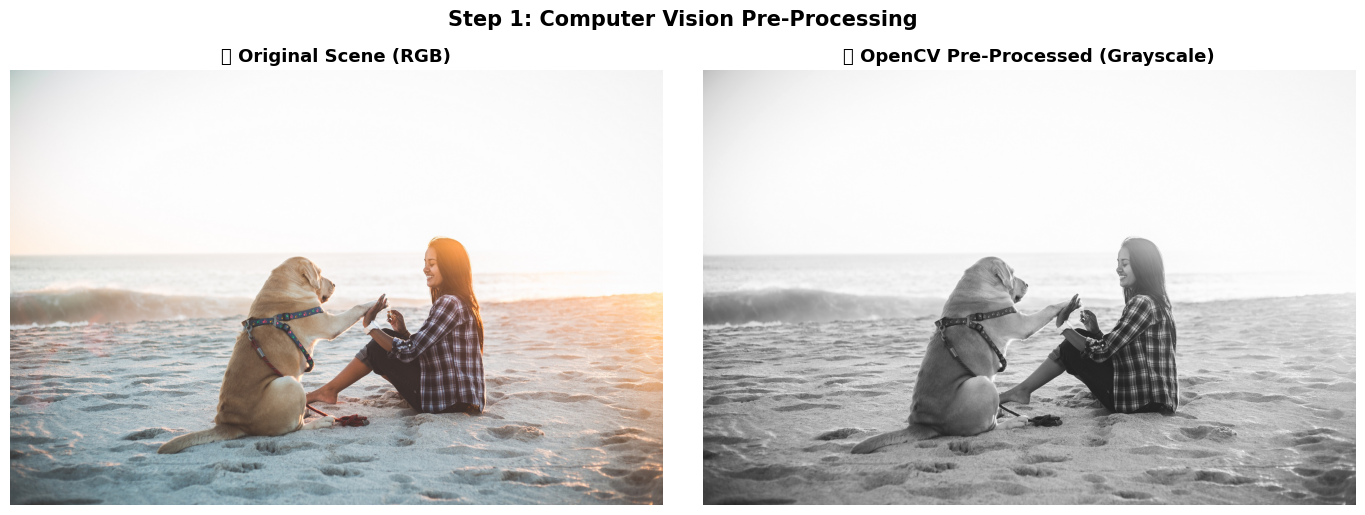


   📊 COMPUTER VISION ANALYSIS REPORT
  Resolution     : 2048 x 1365 pixels
  Channels       : 3 (RGB)
  Aspect Ratio   : 1.50
  Brightness     : 203.7 / 255
  Contrast (std) : 55.7
  Condition      : Bright scene


In [4]:
# ==============================================================================
# CELL 2: Image Download & OpenCV Pre-Processing
# ==============================================================================

IMAGE_URL = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'

# ── Download image ────────────────────────────────────────────────────────────
print('🔽 Sample scene image download ho rahi hai...')
response = requests.get(IMAGE_URL, stream=True, timeout=15)
response.raise_for_status()

with open(IMAGE_PATH, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
print(f'✅ Image saved: {IMAGE_PATH}')

# ── OpenCV Analysis (Vision Pre-Processing) ───────────────────────────────────
cv_image  = cv2.imread(IMAGE_PATH)
rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
gray      = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)

h, w, c = cv_image.shape
mean_brightness = np.mean(gray)
std_contrast    = np.std(gray)

# ── Display: Original + Grayscale side by side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(rgb_image)
axes[0].set_title('📷 Original Scene (RGB)', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('🔬 OpenCV Pre-Processed (Grayscale)', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Step 1: Computer Vision Pre-Processing', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Image Stats ───────────────────────────────────────────────────────────────
print('\n' + '=' * 50)
print('   📊 COMPUTER VISION ANALYSIS REPORT')
print('=' * 50)
print(f'  Resolution     : {w} x {h} pixels')
print(f'  Channels       : {c} (RGB)')
print(f'  Aspect Ratio   : {w/h:.2f}')
print(f'  Brightness     : {mean_brightness:.1f} / 255')
print(f'  Contrast (std) : {std_contrast:.1f}')
print(f'  Condition      : {"Bright" if mean_brightness > 127 else "Dark"} scene')
print('=' * 50)

In [5]:
# ==============================================================================
# CELL 3: Load Pre-Trained Multi-Modal Models
# Pehli baar chalane par Hugging Face se download hoga (~1.5 GB)
# ==============================================================================

print('🔄 Model A: Image Captioning model load ho raha hai...')
print('   (Pehli baar ~900MB download hoga — internet chahiye)\n')

# ── Model A: Image Captioning ─────────────────────────────────────────────────
caption_processor = BlipProcessor.from_pretrained(config['model_name'])
caption_model     = BlipForConditionalGeneration.from_pretrained(
    config['model_name']
).to(DEVICE)

print(f'✅ Model A loaded on {DEVICE.upper()}')
print(f'   Parameters: {sum(p.numel() for p in caption_model.parameters()) / 1e6:.1f} Million')

print('\n🔄 Model B: Visual Question Answering model load ho raha hai...')

# ── Model B: Visual Question Answering ───────────────────────────────────────
vqa_processor = BlipProcessor.from_pretrained(config['vqa_model_name'])
vqa_model     = BlipForQuestionAnswering.from_pretrained(
    config['vqa_model_name']
).to(DEVICE)

print(f'✅ Model B loaded on {DEVICE.upper()}')
print(f'   Parameters: {sum(p.numel() for p in vqa_model.parameters()) / 1e6:.1f} Million')

print('\n' + '=' * 50)
print('  🎯 Both Models Ready for Inference!')
print('=' * 50)

🔄 Model A: Image Captioning model load ho raha hai...
   (Pehli baar ~900MB download hoga — internet chahiye)



model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

✅ Model A loaded on CPU
   Parameters: 446.3 Million

🔄 Model B: Visual Question Answering model load ho raha hai...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

✅ Model B loaded on CPU
   Parameters: 361.2 Million

  🎯 Both Models Ready for Inference!


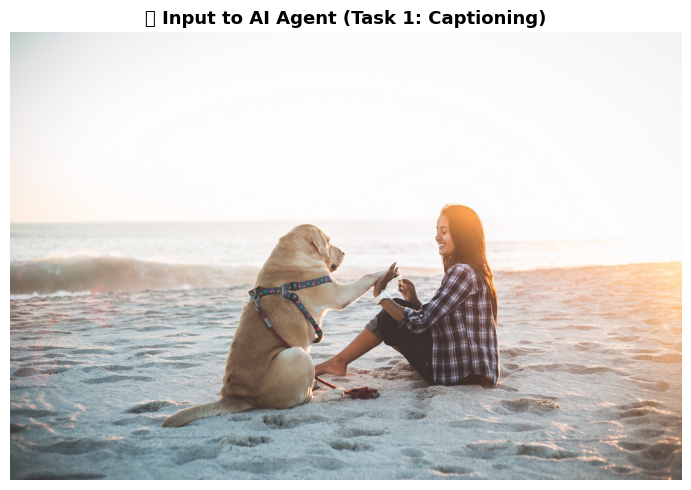


🧠 Model scene analyze kar raha hai...

════════════════════════════════════════════════════════════
   👁️  AI AGENT — VISION PERCEPTION OUTPUT
════════════════════════════════════════════════════════════
  Task        : Unconditional Image Captioning
  Perception  : THERE IS A WOMAN AND A DOG ON THE BEACH PLAYING WITH EACH OTHER
════════════════════════════════════════════════════════════


In [8]:
# ==============================================================================
# CELL 4: Task 1 — Unconditional Image Captioning
# Model ko koi text hint nahi dein — sirf raw image input
# ==============================================================================

# ── Load & display image ──────────────────────────────────────────────────────
raw_image = Image.open(IMAGE_PATH).convert('RGB')

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.imshow(raw_image)
ax.set_title('🎯 Input to AI Agent (Task 1: Captioning)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# ── Unconditional inference ───────────────────────────────────────────────────
print('\n🧠 Model scene analyze kar raha hai...')
inputs = caption_processor(raw_image, return_tensors='pt').to(DEVICE)

with torch.no_grad():
    output_ids = caption_model.generate(
        **inputs,
        max_new_tokens=config['max_new_tokens'],
        num_beams=config['num_beams'],
        min_length=config['min_length'],
        repetition_penalty=config['repetition_penalty']
    )

unconditional_caption = caption_processor.decode(output_ids[0], skip_special_tokens=True)

# ── Display result ────────────────────────────────────────────────────────────
print('\n' + '═' * 60)
print('   👁️  AI AGENT — VISION PERCEPTION OUTPUT')
print('═' * 60)
print(f'  Task        : Unconditional Image Captioning')
print(f'  Perception  : {unconditional_caption.upper()}')
print('═' * 60)

In [9]:
# ==============================================================================
# CELL 5: Task 2 — Conditional Captioning (Multi-Modal Fusion)
# Vision + Language context dono ek sath model ko dein
# ==============================================================================

# ── Multiple context scenarios (jaise real-world user queries) ────────────────
context_prompts = [
    "a photograph of",
    "the scene shows",
    "this image contains"
]

print('🔗 MULTI-MODAL FUSION: Vision + Language Context')
print('=' * 60)

conditional_results = []

for i, prompt in enumerate(context_prompts, 1):
    inputs = caption_processor(
        raw_image, prompt, return_tensors='pt'
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = caption_model.generate(
            **inputs,
            max_new_tokens=config['max_new_tokens'],
            num_beams=config['num_beams'],
            repetition_penalty=config['repetition_penalty']
        )

    result = caption_processor.decode(output_ids[0], skip_special_tokens=True)
    conditional_results.append(result)

    print(f'  Context {i}: "{prompt}"')
    print(f'  Output  : {result}')
    print(f'  {"─" * 55}')

print('\n✅ Fusion complete — model ne vision + language dono process kiye!')

🔗 MULTI-MODAL FUSION: Vision + Language Context
  Context 1: "a photograph of"
  Output  : a photograph of a woman petting a dog on the beach
  ───────────────────────────────────────────────────────
  Context 2: "the scene shows"
  Output  : the scene shows a woman and her dog on the beach
  ───────────────────────────────────────────────────────
  Context 3: "this image contains"
  Output  : this image contains a woman and a dog on the beach
  ───────────────────────────────────────────────────────

✅ Fusion complete — model ne vision + language dono process kiye!


In [10]:
# ==============================================================================
# CELL 6: Task 3 — Visual Question Answering (VQA)
# Image + Natural Language Question → Answer
# ==============================================================================

# ── Define questions to ask the agent ─────────────────────────────────────────
questions = [
    "What is happening in this image?",
    "What time of day does it appear to be?",
    "How many people are visible?",
    "Is this indoors or outdoors?",
    "What is the main subject of this image?"
]

print('❓ VISUAL QUESTION ANSWERING (VQA) — AI Agent Reasoning')
print('=' * 60)

vqa_results = []

for i, question in enumerate(questions, 1):
    inputs = vqa_processor(
        raw_image,
        question,
        return_tensors='pt'
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = vqa_model.generate(
            **inputs,
            max_new_tokens=50
        )

    answer = vqa_processor.decode(output_ids[0], skip_special_tokens=True)
    vqa_results.append({'question': question, 'answer': answer})

    print(f'  Q{i}: {question}')
    print(f'  A{i}: {answer.upper()}')
    print(f'  {"─" * 55}')

print('\n✅ VQA complete — model ne har sawaal ka jawab diya!')

❓ VISUAL QUESTION ANSWERING (VQA) — AI Agent Reasoning
  Q1: What is happening in this image?
  A1: WOMAN AND DOG AT BEACH
  ───────────────────────────────────────────────────────
  Q2: What time of day does it appear to be?
  A2: SUNSET
  ───────────────────────────────────────────────────────
  Q3: How many people are visible?
  A3: ONE
  ───────────────────────────────────────────────────────
  Q4: Is this indoors or outdoors?
  A4: OUTDOORS
  ───────────────────────────────────────────────────────
  Q5: What is the main subject of this image?
  A5: DOG AND WOMAN
  ───────────────────────────────────────────────────────

✅ VQA complete — model ne har sawaal ka jawab diya!


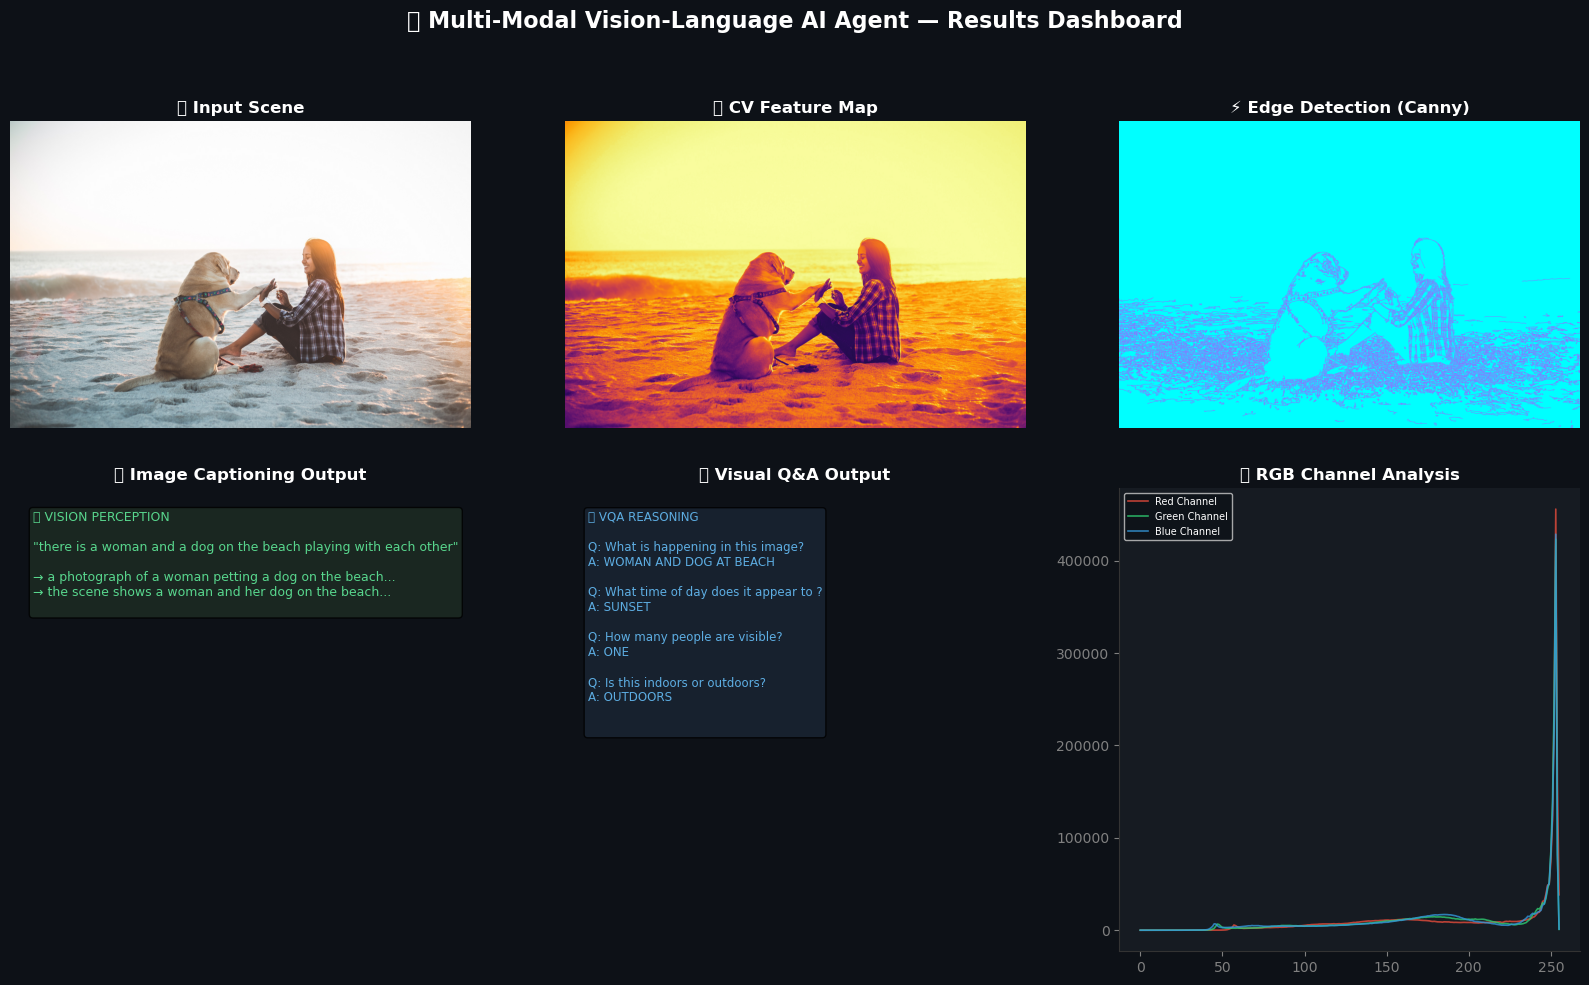

✅ Dashboard saved: outputs/results_dashboard.png


In [11]:
# ==============================================================================
# CELL 7: Results Visualization Dashboard
# ==============================================================================

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    '🤖 Multi-Modal Vision-Language AI Agent — Results Dashboard',
    fontsize=16, fontweight='bold', color='white', y=0.98
)

# ── Panel 1: Original Image ───────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.imshow(raw_image)
ax1.set_title('📷 Input Scene', color='white', fontweight='bold')
ax1.axis('off')
ax1.set_facecolor('#0d1117')

# ── Panel 2: OpenCV Grayscale ─────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
cv_img = cv2.imread(IMAGE_PATH)
gray   = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
ax2.imshow(gray, cmap='inferno')
ax2.set_title('🔬 CV Feature Map', color='white', fontweight='bold')
ax2.axis('off')
ax2.set_facecolor('#0d1117')

# ── Panel 3: Edge Detection (Canny) ──────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
edges = cv2.Canny(gray, threshold1=50, threshold2=150)
ax3.imshow(edges, cmap='cool')
ax3.set_title('⚡ Edge Detection (Canny)', color='white', fontweight='bold')
ax3.axis('off')
ax3.set_facecolor('#0d1117')

# ── Panel 4: Caption Output ────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_facecolor('#161b22')
ax4.axis('off')
caption_text = f'👁️ VISION PERCEPTION\n\n"{unconditional_caption}"\n\n'
for res in conditional_results[:2]:
    caption_text += f'→ {res[:60]}...\n'
ax4.text(0.05, 0.95, caption_text, transform=ax4.transAxes,
         fontsize=9, color='#58d68d', va='top', wrap=True,
         bbox=dict(boxstyle='round', facecolor='#1e2d24', alpha=0.8))
ax4.set_title('🧠 Image Captioning Output', color='white', fontweight='bold')

# ── Panel 5: VQA Results ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
ax5.set_facecolor('#161b22')
ax5.axis('off')
vqa_text = '❓ VQA REASONING\n\n'
for r in vqa_results[:4]:
    short_q = r['question'][:35] + '?' if len(r['question']) > 35 else r['question']
    vqa_text += f'Q: {short_q}\nA: {r["answer"].upper()}\n\n'
ax5.text(0.05, 0.95, vqa_text, transform=ax5.transAxes,
         fontsize=8.5, color='#5dade2', va='top',
         bbox=dict(boxstyle='round', facecolor='#1a2634', alpha=0.8))
ax5.set_title('❓ Visual Q&A Output', color='white', fontweight='bold')

# ── Panel 6: Pixel Intensity Histogram ───────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor('#161b22')
rgb_arr = np.array(raw_image)
colors_hist = ['#e74c3c', '#2ecc71', '#3498db']
labels_hist = ['Red Channel', 'Green Channel', 'Blue Channel']
for ch, col, lbl in zip(range(3), colors_hist, labels_hist):
    hist = cv2.calcHist([rgb_arr], [ch], None, [256], [0, 256])
    ax6.plot(hist.flatten(), color=col, alpha=0.8, linewidth=1.2, label=lbl)
ax6.set_title('📊 RGB Channel Analysis', color='white', fontweight='bold')
ax6.legend(fontsize=7, facecolor='#0d1117', labelcolor='white')
ax6.set_facecolor('#161b22')
ax6.tick_params(colors='gray')
ax6.spines['bottom'].set_color('#333')
ax6.spines['left'].set_color('#333')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/results_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('✅ Dashboard saved: outputs/results_dashboard.png')

In [12]:
# ==============================================================================
# CELL 8: Production-Style Inference Logging
# Real-world AI systems mein sab kuch log hota hai
# ==============================================================================

timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
img_arr   = np.array(raw_image)
h, w      = img_arr.shape[:2]

log_content = f"""{'='*65}
  MULTI-MODAL AI AGENT — INFERENCE LOG
{'='*65}
Timestamp       : {timestamp}
Device          : {DEVICE.upper()}
Caption Model   : {config['model_name']}
VQA Model       : {config['vqa_model_name']}
Image Path      : {IMAGE_PATH}
Resolution      : {w} x {h} pixels
Dataset Ref     : {config['dataset_reference']['name']}
Kaggle Source   : {config['dataset_reference']['source']}
{'─'*65}

[TASK 1] UNCONDITIONAL IMAGE CAPTIONING
Output : {unconditional_caption}

[TASK 2] CONDITIONAL CAPTIONING (MULTI-MODAL FUSION)
"""

for i, (prompt, result) in enumerate(zip(context_prompts, conditional_results), 1):
    log_content += f'  Context {i} Prompt : "{prompt}"\n'
    log_content += f'  Context {i} Output : {result}\n\n'

log_content += f"[TASK 3] VISUAL QUESTION ANSWERING (VQA)\n"
for i, r in enumerate(vqa_results, 1):
    log_content += f'  Q{i}: {r["question"]}\n'
    log_content += f'  A{i}: {r["answer"]}\n\n'

log_content += f"{'='*65}\n"
log_content += f"STATUS: SUCCESS — All 3 tasks completed\n"
log_content += f"{'='*65}\n"

# ── Write log to file ─────────────────────────────────────────────────────────
with open(LOG_FILE, 'w', encoding='utf-8') as f:
    f.write(log_content)

print(log_content)
print(f'💾 Log file saved: {LOG_FILE}')

  MULTI-MODAL AI AGENT — INFERENCE LOG
Timestamp       : 2026-06-14 05:31:53
Device          : CPU
Caption Model   : Salesforce/blip-image-captioning-large
VQA Model       : Salesforce/blip-vqa-base
Image Path      : ../data\sample_scene.jpg
Resolution      : 2048 x 1365 pixels
Dataset Ref     : Flickr8k
Kaggle Source   : https://www.kaggle.com/datasets/adityajn105/flickr8k
─────────────────────────────────────────────────────────────────

[TASK 1] UNCONDITIONAL IMAGE CAPTIONING
Output : there is a woman and a dog on the beach playing with each other

[TASK 2] CONDITIONAL CAPTIONING (MULTI-MODAL FUSION)
  Context 1 Prompt : "a photograph of"
  Context 1 Output : a photograph of a woman petting a dog on the beach

  Context 2 Prompt : "the scene shows"
  Context 2 Output : the scene shows a woman and her dog on the beach

  Context 3 Prompt : "this image contains"
  Context 3 Output : this image contains a woman and a dog on the beach

[TASK 3] VISUAL QUESTION ANSWERING (VQA)
  Q1: What